In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import warnings, os
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [44]:
# ── 1. Load & clean ───────────────────────────────────────────────────────────
df = pd.read_csv("/kaggle/input/datasets/alieldinalaa/solship/data (1).csv") # Replace with /kaggle/input/... if on Kaggle
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# ── 2. Time features ─────────────────────────────────────────────────────────
df["hour"]        = df.index.hour
df["month"]       = df.index.month
df["day_of_week"] = df.index.dayofweek

TARGET   = "load_p"
FEATURES = [c for c in [
    "load_p", "pv_p", "temperature_2m", "apparent_temperature",
    "relative_humidity_2m", "shortwave_radiation", "cloud_cover",
    "wind_speed_10m", "hour", "month", "day_of_week"
] if c in df.columns]

data = df[FEATURES].dropna()
print(f"Full dataset: {data.index.min()} -> {data.index.max()}  |  shape {data.shape}")
display(data.head())

Full dataset: 2024-01-01 00:00:00 -> 2025-12-31 00:00:00  |  shape (70077, 11)


,load_p,pv_p,temperature_2m,apparent_temperature,relative_humidity_2m,shortwave_radiation,cloud_cover,wind_speed_10m,hour,month,day_of_week
timestamp,,,,,,,,,,,
2024-01-01 00:00:00,3.05,0.0,5.1,3.0,88,0.0,60,4.2,0,1,0
2024-01-01 00:15:00,0.34,0.0,5.1,2.9,87,0.0,57,3.9,0,1,0
2024-01-01 00:30:00,0.37,0.0,5.1,3.0,85,0.0,54,3.1,0,1,0
2024-01-01 00:45:00,0.37,0.0,5.0,3.0,83,0.0,50,2.3,0,1,0
2024-01-01 01:00:00,2.40,0.0,4.9,2.9,82,0.0,47,1.6,1,1,0


In [45]:
SEQ_LEN  = 4 * 336
PRED_LEN = 48
BATCH    = 32

TRAIN_START    = "2024-01-01"
TRAIN_END      = "2025-02-28 23:00"
VAL_START      = "2025-03-01"
VAL_END        = "2025-03-31 23:00"
TEST1_START    = "2025-04-01"
TEST1_END      = "2025-04-30 23:00"
FINETUNE_START = "2025-04-01"
FINETUNE_END   = "2025-08-31 23:00"
TEST2_START    = "2025-09-01"
TEST2_END      = "2025-09-30 23:00"

df_train    = data.loc[TRAIN_START    : TRAIN_END]
df_val      = data.loc[VAL_START      : VAL_END]
df_test1    = data.loc[TEST1_START    : TEST1_END]
df_finetune = data.loc[FINETUNE_START : FINETUNE_END]
df_test2    = data.loc[TEST2_START    : TEST2_END]

for name, d in [("Train",    df_train),
                ("Val",      df_val),
                ("Test-1",   df_test1),
                ("Finetune", df_finetune),
                ("Test-2",   df_test2)]:
    print(f"{name:10s}: {d.index.min().date()} -> {d.index.max().date()}  ({len(d):,} rows)")

scaler = StandardScaler()
scaler.fit(df_train.values)

def scale(d): return scaler.transform(d.values).astype(np.float32)

arr_train    = scale(df_train)
arr_val      = scale(df_val)
arr_test1    = scale(df_test1)
arr_finetune = scale(df_finetune)
arr_test2    = scale(df_test2)

N_FEAT = arr_train.shape[1]
print(f"\nN_FEAT = {N_FEAT}")

Train     : 2024-01-01 -> 2025-02-28  (40,797 rows)
Val       : 2025-03-01 -> 2025-03-31  (2,969 rows)
Test-1    : 2025-04-01 -> 2025-04-30  (2,877 rows)
Finetune  : 2025-04-01 -> 2025-08-31  (14,685 rows)
Test-2    : 2025-09-01 -> 2025-09-30  (2,877 rows)

N_FEAT = 11


In [46]:
class TSDataset(Dataset):
    def __init__(self, arr, seq_len, pred_len, context=None):
        if context is not None:
            arr = np.concatenate([context, arr], axis=0)
        self.arr = arr
        self.sl  = seq_len
        self.pl  = pred_len

    def __len__(self):
        return len(self.arr) - self.sl - self.pl + 1

    def __getitem__(self, i):
        x = self.arr[i          : i + self.sl]
        y = self.arr[i + self.sl: i + self.sl + self.pl, 0]   # col 0 = load_p
        return torch.tensor(x), torch.tensor(y)

ctx_for_val      = arr_train[-SEQ_LEN:]
ctx_for_test1    = arr_val[-SEQ_LEN:]
ctx_for_finetune = arr_test1[-SEQ_LEN:]
ctx_for_test2    = arr_finetune[-SEQ_LEN:]

ds_train    = TSDataset(arr_train,    SEQ_LEN, PRED_LEN)
ds_val      = TSDataset(arr_val,      SEQ_LEN, PRED_LEN, ctx_for_val)
ds_test1    = TSDataset(arr_test1,    SEQ_LEN, PRED_LEN, ctx_for_test1)
ds_finetune = TSDataset(arr_finetune, SEQ_LEN, PRED_LEN, ctx_for_finetune)
ds_test2    = TSDataset(arr_test2,    SEQ_LEN, PRED_LEN, ctx_for_test2)

dl_train    = DataLoader(ds_train,    BATCH, shuffle=True,  drop_last=True)
dl_val      = DataLoader(ds_val,      BATCH, shuffle=False)
dl_test1    = DataLoader(ds_test1,    BATCH, shuffle=False)
dl_finetune = DataLoader(ds_finetune, BATCH, shuffle=True,  drop_last=True)
dl_test2    = DataLoader(ds_test2,    BATCH, shuffle=False)

In [47]:
def compute_metrics(trues, preds, label=""):
    def inv(v):
        dummy       = np.zeros((len(v), N_FEAT), dtype=np.float32)
        dummy[:, 0] = v
        return scaler.inverse_transform(dummy)[:, 0]

    t = inv(trues.flatten())
    p = inv(preds.flatten())

    rmse  = float(np.sqrt(np.mean((t - p) ** 2)))
    mae   = float(np.mean(np.abs(t - p)))
    nrmse = float(rmse / (t.max() - t.min() + 1e-8))
    
    # MAPE CAUTION: Loads can be zero or close to zero. We clamp the denominator to a small safe value.
    t_safe = np.where(np.abs(t) < 1e-4, 1e-4, t)
    mape = float(np.mean(np.abs((t - p) / t_safe))) * 100

    print(f"  {label}")
    print(f"    RMSE  = {rmse:.4f} kW")
    print(f"    MAE   = {mae:.4f} kW")
    print(f"    NRMSE = {nrmse:.4f}")
    print(f"    MAPE  = {mape:.4f} %")
    return {"RMSE": round(rmse, 4), "MAE": round(mae, 4), "NRMSE": round(nrmse, 4), "MAPE(%)": round(mape, 2)}

def run_epoch(model, dl, opt, criterion, training=True):
    model.train() if training else model.eval()
    total = 0
    ctx   = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x, y in dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if training: opt.zero_grad()
            loss = criterion(model(x), y)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item()
    return total / len(dl)

def train_phase(model, dl_tr, dl_vl, epochs=20, lr=1e-3, tag="Phase"):
    # Heavily penalized weight_decay (1e-3) to force sparsity & prevent overfitting
    opt       = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    criterion = nn.MSELoss()
    history   = {"train": [], "val": []}

    print(f"\n{'─'*55}")
    print(f"  {tag}  |  epochs={epochs}  lr={lr}")
    print(f"{'─'*55}")
    for ep in range(1, epochs + 1):
        tr = run_epoch(model, dl_tr, opt, criterion, training=True)
        vl = run_epoch(model, dl_vl, opt, criterion, training=False)
        scheduler.step(vl)
        history["train"].append(tr)
        history["val"].append(vl)
        # Printing EVERY epoch to monitor overfitting closely 
        print(f"  Epoch {ep:3d}/{epochs}  Train-MSE={tr:.5f}  Val-MSE={vl:.5f}")
    return history

def collect_preds(model, dl):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in dl:
            preds.append(model(x.to(DEVICE)).cpu().numpy())
            trues.append(y.numpy())
    return np.concatenate(preds), np.concatenate(trues)

def plot_loss(h1, h2=None, title="Loss curves"):
    fig, ax = plt.subplots(figsize=(11, 4))
    ep1 = range(1, len(h1["train"]) + 1)
    ax.plot(ep1, h1["train"], label="Phase-1 train")
    ax.plot(ep1, h1["val"],   label="Phase-1 val")
    if h2:
        off = len(h1["train"])
        ep2 = range(off + 1, off + len(h2["train"]) + 1)
        ax.plot(ep2, h2["train"], "--", label="Phase-2 train")
        ax.plot(ep2, h2["val"],   "--", label="Phase-2 val")
        ax.axvline(off + 0.5, color="k", linestyle=":", lw=1.2, label="fine-tune start")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled)")
    ax.legend(); plt.tight_layout(); plt.show()

def plot_forecast(trues, preds, label, n=300):
    def inv(v):
        dummy       = np.zeros((len(v), N_FEAT), dtype=np.float32)
        dummy[:, 0] = v
        return scaler.inverse_transform(dummy)[:, 0]

    t = inv(trues.flatten())[:n]
    p = inv(preds.flatten())[:n]

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(t, label="Ground Truth", alpha=0.85)
    ax.plot(p, label="Prediction",   alpha=0.85)
    ax.set_title(f"{label}  (first {n} steps, kW)")
    ax.set_ylabel("load_p (kW)"); ax.legend()
    plt.tight_layout(); plt.show()

In [48]:
class RevIN(nn.Module):
    def __init__(self, n_feat, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.w   = nn.Parameter(torch.ones(n_feat))
        self.b   = nn.Parameter(torch.zeros(n_feat))
        self._mean = self._std = None

    def forward(self, x, mode):
        if mode == "norm":
            self._mean = x.mean(1, keepdim=True).detach()
            self._std  = x.std(1,  keepdim=True, unbiased=False).detach() + self.eps
            return (x - self._mean) / self._std * self.w + self.b
        else:
            return ((x - self.b) / (self.w + 1e-8)) * self._std + self._mean

class ResidualBlock(nn.Module):
    """ Standard Dense Residual Block used in TiDE """
    def __init__(self, d_model, dropout):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_model)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(d_model, d_model)
        self.dropout2 = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout1(out)
        out = self.fc2(out)
        out = self.dropout2(out)
        return self.norm(x + out)

class TiDE(nn.Module):
    def __init__(self, seq_len, pred_len, n_feat, d_model=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.revin = RevIN(n_feat)
        
        # Flattened input (Batch, Seq_len * Features)
        in_dim = seq_len * n_feat
        self.feature_proj = nn.Linear(in_dim, d_model)
        
        # Encoder & Decoder MLPs
        self.encoder = nn.Sequential(*[ResidualBlock(d_model, dropout) for _ in range(n_layers)])
        self.decoder = nn.Sequential(*[ResidualBlock(d_model, dropout) for _ in range(n_layers)])
        
        self.out_proj = nn.Linear(d_model, pred_len)
        
        # Global residual connection (from past target to future prediction)
        self.global_res = nn.Linear(seq_len, pred_len)

    def forward(self, x):
        # Normalization
        x = self.revin(x, "norm")
        
        # Global residual path based entirely on the target (column 0)
        past_target = x[:, :, 0]
        res = self.global_res(past_target)
        
        # TiDE Dense Processing
        x_flat = x.flatten(1)
        hidden = self.feature_proj(x_flat)
        hidden = self.encoder(hidden)
        hidden = self.decoder(hidden)
        out = self.out_proj(hidden)
        
        # Add global residual mapping
        out = out + res
        
        # Denormalization
        std0 = self.revin._std[:, :, 0]
        mean0 = self.revin._mean[:, :, 0]
        w0, b0 = self.revin.w[0], self.revin.b[0]
        out = ((out - b0) / (w0 + 1e-8)) * std0 + mean0
        
        return out

Model     : TiDE
Parameters: 2,096,374

───────────────────────────────────────────────────────
  Phase-1  |  epochs=20  lr=0.001
───────────────────────────────────────────────────────
  Epoch   1/20  Train-MSE=0.68921  Val-MSE=0.61300
  Epoch   2/20  Train-MSE=0.64696  Val-MSE=0.60927
  Epoch   3/20  Train-MSE=0.63988  Val-MSE=0.61303
  Epoch   4/20  Train-MSE=0.63434  Val-MSE=0.62101
  Epoch   5/20  Train-MSE=0.63086  Val-MSE=0.62178
  Epoch   6/20  Train-MSE=0.62945  Val-MSE=0.62733
  Epoch   7/20  Train-MSE=0.57700  Val-MSE=0.59497
  Epoch   8/20  Train-MSE=0.57162  Val-MSE=0.59849
  Epoch   9/20  Train-MSE=0.57063  Val-MSE=0.60367
  Epoch  10/20  Train-MSE=0.56986  Val-MSE=0.59953
  Epoch  11/20  Train-MSE=0.56976  Val-MSE=0.59447
  Epoch  12/20  Train-MSE=0.56886  Val-MSE=0.60263
  Epoch  13/20  Train-MSE=0.56947  Val-MSE=0.61331
  Epoch  14/20  Train-MSE=0.56809  Val-MSE=0.60983
  Epoch  15/20  Train-MSE=0.56718  Val-MSE=0.59764
  Epoch  16/20  Train-MSE=0.53916  Val-MSE=0.5975

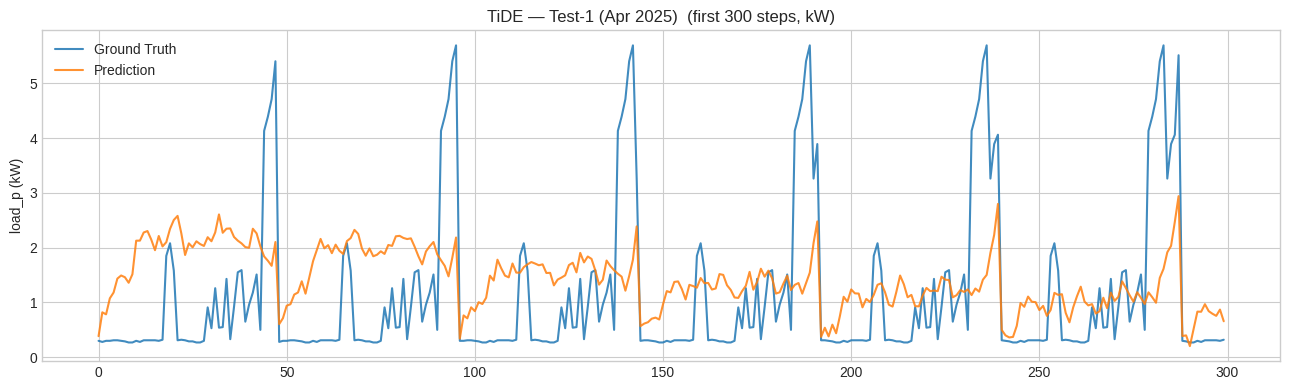

Checkpoint saved -> tide_phase1.pt
Phase-1 checkpoint loaded for fine-tuning.

───────────────────────────────────────────────────────
  Phase-2 fine-tune  |  epochs=10  lr=0.0002
───────────────────────────────────────────────────────
  Epoch   1/10  Train-MSE=0.57704  Val-MSE=0.47715
  Epoch   2/10  Train-MSE=0.49653  Val-MSE=0.51552
  Epoch   3/10  Train-MSE=0.46700  Val-MSE=0.54870
  Epoch   4/10  Train-MSE=0.45097  Val-MSE=0.55429
  Epoch   5/10  Train-MSE=0.43707  Val-MSE=0.57903
  Epoch   6/10  Train-MSE=0.41335  Val-MSE=0.58319
  Epoch   7/10  Train-MSE=0.40445  Val-MSE=0.59381
  Epoch   8/10  Train-MSE=0.39706  Val-MSE=0.61692
  Epoch   9/10  Train-MSE=0.39029  Val-MSE=0.63251
  Epoch  10/10  Train-MSE=0.37770  Val-MSE=0.63620

== Test-2 (September 2025) ==
  TiDE | Test-2 (Sep-2025)
    RMSE  = 1.0234 kW
    MAE   = 0.7130 kW
    NRMSE = 0.1837
    MAPE  = 163.0923 %


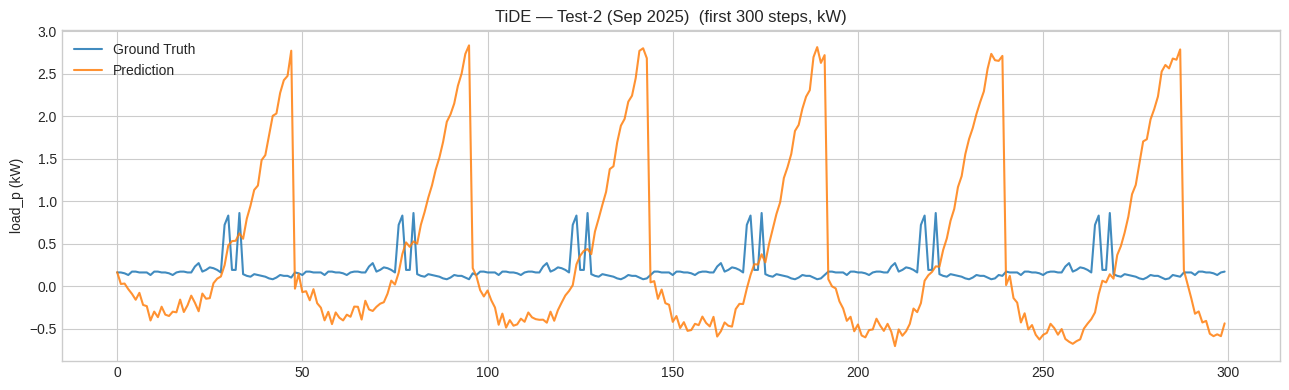

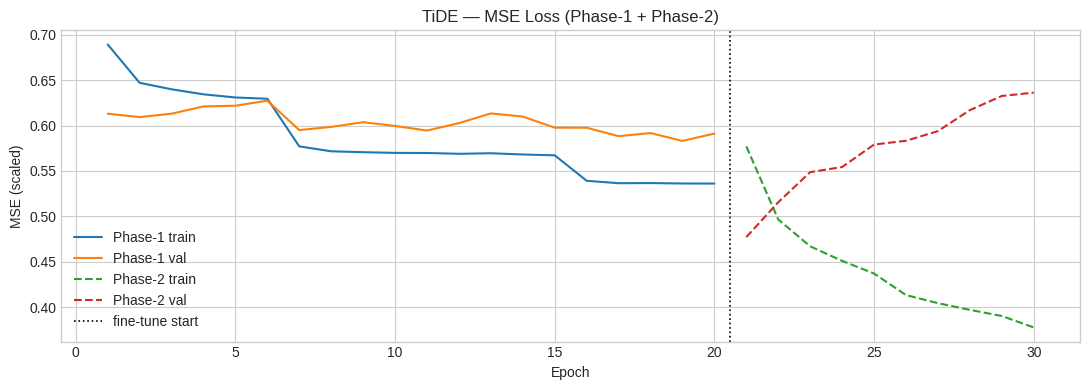

,RMSE,MAE,NRMSE,MAPE(%)
Phase,,,,
Phase-1 | Test-1 (Apr-2025),1.0248,0.7115,0.1731,151.26
Phase-2 | Test-2 (Sep-2025),1.0234,0.7130,0.1837,163.09


In [49]:
MODEL_LABEL = "TiDE"

# High dropout (0.3) and shallow layers to combat overfitting. 
# Increase layers if it underfits, decrease d_model if it overfits.
model = TiDE(SEQ_LEN, PRED_LEN, N_FEAT, d_model=128, n_layers=2, dropout=0.3).to(DEVICE)
print(f"Model     : {MODEL_LABEL}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Phase 1
hist1 = train_phase(model, dl_train, dl_val, epochs=20, lr=1e-3, tag="Phase-1")

print("\n== Test-1 (April 2025) ==")
preds1, trues1 = collect_preds(model, dl_test1)
metrics1 = compute_metrics(trues1, preds1, label=f"{MODEL_LABEL} | Test-1 (Apr-2025)")
plot_forecast(trues1, preds1, f"{MODEL_LABEL} — Test-1 (Apr 2025)")

# Save Checkpoint
CKPT = "tide_phase1.pt"
torch.save(model.state_dict(), CKPT)
print(f"Checkpoint saved -> {CKPT}")

# Phase 2 Fine-tuning
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
print("Phase-1 checkpoint loaded for fine-tuning.")

hist2 = train_phase(model, dl_finetune, dl_test2, epochs=10, lr=2e-4, tag="Phase-2 fine-tune")

print("\n== Test-2 (September 2025) ==")
preds2, trues2 = collect_preds(model, dl_test2)
metrics2 = compute_metrics(trues2, preds2, label=f"{MODEL_LABEL} | Test-2 (Sep-2025)")
plot_forecast(trues2, preds2, f"{MODEL_LABEL} — Test-2 (Sep 2025)")

# Results Visualization
plot_loss(hist1, hist2, title=f"{MODEL_LABEL} — MSE Loss (Phase-1 + Phase-2)")

summary = pd.DataFrame([
    {"Phase": "Phase-1  |  Test-1 (Apr-2025)", **metrics1},
    {"Phase": "Phase-2  |  Test-2 (Sep-2025)", **metrics2},
]).set_index("Phase")
display(summary)